In [ ]:
import argparse
import itertools
import json

In [84]:
import numpy as np 
import matplotlib.pyplot as plt

from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.utils.args import DefaultArgumentParser

In [85]:
string_args = [
    "--start-date", "2024-01-01",
    "--stop-date", "2024-06-01",
]

args = DefaultArgumentParser.parse(args=string_args)

In [86]:
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame)
sdf

,open,high,low,close,volume,trade
timestamp,,,,,,
1569456000,8428.15,8464.40,7700.67,8060.15,60065.945,449.0
1569542400,8061.98,8260.00,7851.94,8176.52,40034.653,504.0
1569628800,8178.26,8311.00,8001.14,8195.38,33820.919,756.0
1569715200,8199.00,8226.35,7888.98,8041.96,35966.056,1138.0
1569801600,8042.08,8331.89,7709.01,8285.84,54412.520,751.0
...,...,...,...,...,...,...
1709424000,62039.90,63330.90,61339.50,63178.50,200312.503,22965.0
1709510400,63178.50,68600.00,62299.00,68296.40,632882.144,58113.0
1709596800,68296.50,69350.00,59112.00,63747.40,1053025.132,92467.0


In [88]:
df = sdf.copy()
df["tr"] = df.high / df.low - 1
df["roc"] = df.close / df.open - 1
df["csroc"] = np.cumsum(df.roc)
df["scsroc"] = df.csroc.rolling(window=21, min_periods=1, center=True).mean()

df["atr"] = df.tr.rolling(window=10).mean()
df["stdev"] = df.scsroc.rolling(window=10).std()
df["trend"] = df.atr * 0.7 <= df.stdev

print(df.trend.value_counts() / len(df))

df

trend
False    0.88
True     0.12
Name: count, dtype: float64


,open,high,low,close,volume,trade,tr,roc,csroc,scsroc,atr,stdev,trend
timestamp,,,,,,,,,,,,,
1569456000,8428.15,8464.40,7700.67,8060.15,60065.945,449.0,0.099177,-0.043663,-0.043663,-0.031910,NaN,NaN,False
1569542400,8061.98,8260.00,7851.94,8176.52,40034.653,504.0,0.051969,0.014207,-0.029456,-0.031442,NaN,NaN,False
1569628800,8178.26,8311.00,8001.14,8195.38,33820.919,756.0,0.038727,0.002093,-0.027362,-0.031242,NaN,NaN,False
1569715200,8199.00,8226.35,7888.98,8041.96,35966.056,1138.0,0.042765,-0.019154,-0.046516,-0.027648,NaN,NaN,False
1569801600,8042.08,8331.89,7709.01,8285.84,54412.520,751.0,0.080799,0.030311,-0.016205,-0.024562,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1709424000,62039.90,63330.90,61339.50,63178.50,200312.503,22965.0,0.032465,0.018353,3.036243,2.970805,0.047219,0.024375,False
1709510400,63178.50,68600.00,62299.00,68296.40,632882.144,58113.0,0.101141,0.081007,3.117250,2.981517,0.055228,0.023101,False
1709596800,68296.50,69350.00,59112.00,63747.40,1053025.132,92467.0,0.173197,-0.066608,3.050641,2.994693,0.070324,0.023506,False


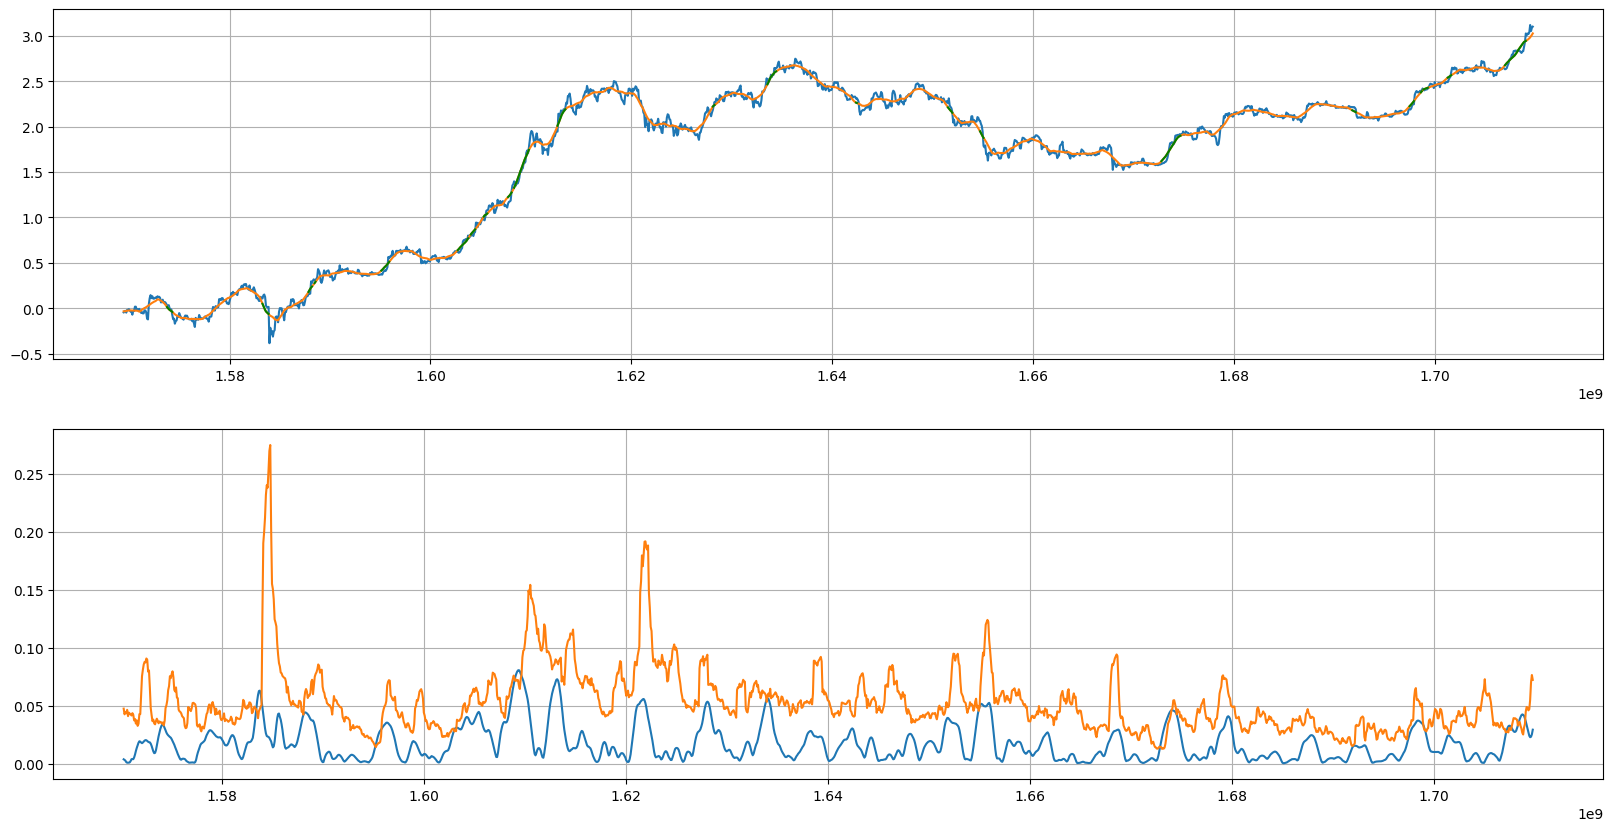

In [91]:
df["tcsroc"] = np.where(df.trend, df.scsroc, np.nan)

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 10))

axs[0].plot(df.csroc)
axs[0].plot(df.scsroc)
axs[0].plot(df.tcsroc, "g")
axs[0].grid()

axs[1].plot(df.stdev)
axs[1].plot(df.atr)
axs[1].grid()